# HW12: временные ряды, temporal split, baseline и GRU
Ноутбук выполняет все обязательные пункты ДЗ: B1, B2, B3, R1, сохранение артефактов и корректную temporal-валидацию.

## 1. Импорты, seed и среда

In [1]:
import json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

SEED = 42
WINDOW_SIZE = 24
HORIZON = 1
MOVING_AVG_WINDOW = 24
HIDDEN_SIZE = 64
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 30

BASE = Path(".")
DATA = BASE / "S12-hw-dataset.csv"
ART = BASE / "artifacts"
FIG = ART / "figures"
ART.mkdir(exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Данные и первичный анализ

Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
NaNs by column:
date      0
target    0
dtype: int64


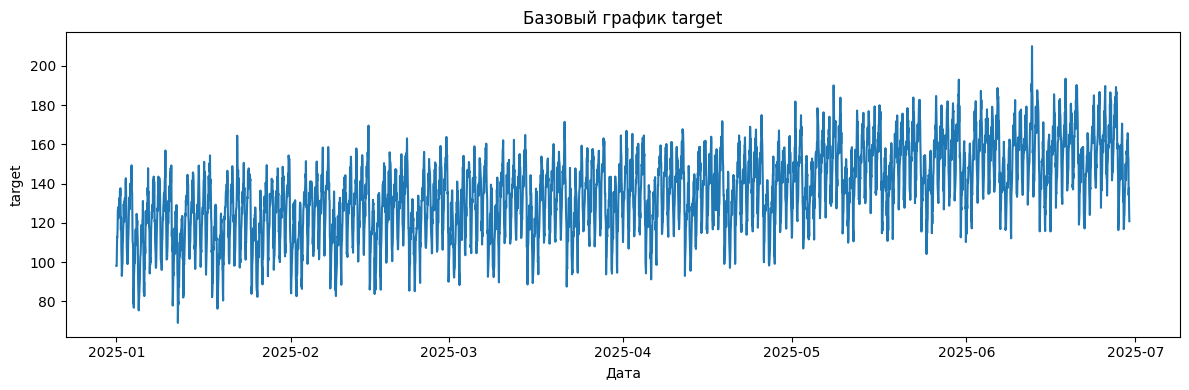

In [2]:
df = pd.read_csv(DATA)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "->", df["date"].max())
print("NaNs by column:")
print(df.isna().sum())

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["target"])
plt.title("Базовый график target")
plt.xlabel("Дата")
plt.ylabel("target")
plt.tight_layout()
plt.show()


## 3. Корректный temporal split

Train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00 rows: 3024
Val  : 2025-05-07 00:00:00 -> 2025-06-02 23:00:00 rows: 648
Test : 2025-06-03 00:00:00 -> 2025-06-29 23:00:00 rows: 648


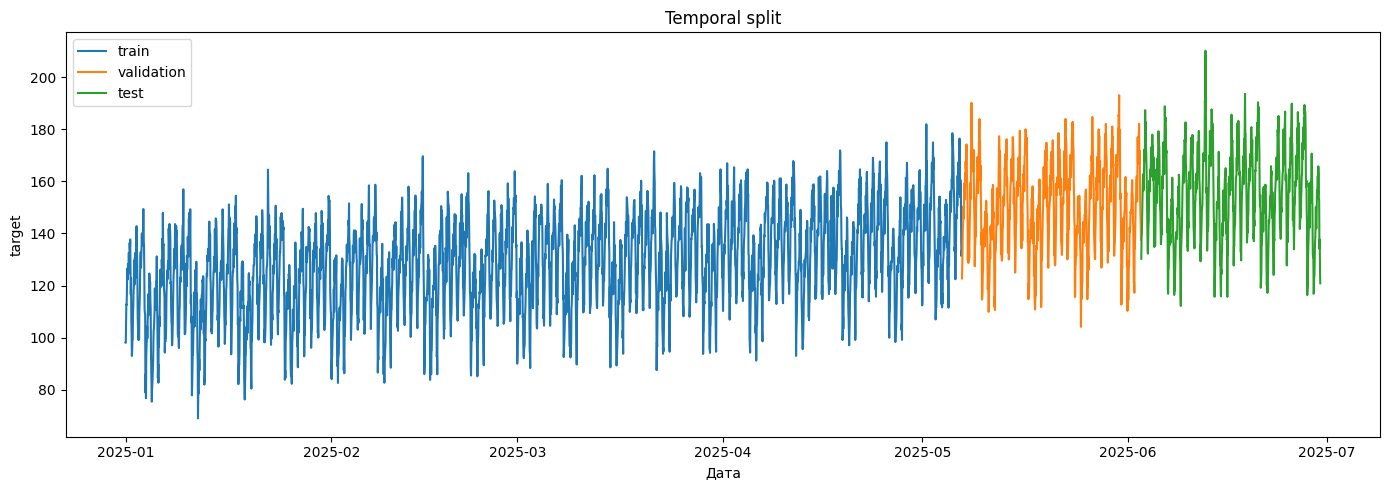

In [3]:
n = len(df)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train + n_val].copy()
test_df = df.iloc[n_train + n_val:].copy()

print("Train:", train_df["date"].min(), "->", train_df["date"].max(), "rows:", len(train_df))
print("Val  :", val_df["date"].min(), "->", val_df["date"].max(), "rows:", len(val_df))
print("Test :", test_df["date"].min(), "->", test_df["date"].max(), "rows:", len(test_df))

plt.figure(figsize=(14, 5))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Temporal split")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "series_split.png", dpi=150)
plt.show()


## Почему random split некорректен
Для временных рядов random split нарушает хронологию и создает утечку информации из будущего в train. В этой работе используется только temporal split, а test используется один раз после выбора лучшей модели по validation.

## 4. Baseline-модели и признаки

In [4]:
def mape(y_true, y_pred):
    d = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / d)) * 100)

def metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": mape(y_true, y_pred),
    }

y = df["target"].to_numpy(float)
val_slice = slice(n_train, n_train + n_val)
test_slice = slice(n_train + n_val, n)

# B1: naive-last
prev = pd.Series(y).shift(1).to_numpy()
b1_val = metrics(y[val_slice], prev[val_slice])

# B2: moving-average
ma = pd.Series(y).shift(1).rolling(MOVING_AVG_WINDOW).mean().to_numpy()
ma = np.where(np.isnan(ma), prev, ma)
b2_val = metrics(y[val_slice], ma[val_slice])

# B3: ridge on lag/rolling/calendar
feat = df.copy()
feat["lag_1"] = feat["target"].shift(1)
feat["lag_7"] = feat["target"].shift(7)
feat["lag_14"] = feat["target"].shift(14)
feat["rolling_mean_7"] = feat["target"].shift(1).rolling(7).mean()
feat["rolling_std_7"] = feat["target"].shift(1).rolling(7).std()
feat["day_of_week"] = feat["date"].dt.dayofweek
feat["hour"] = feat["date"].dt.hour

feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "day_of_week", "hour"]
feat = feat.dropna().reset_index().rename(columns={"index": "orig_idx"})
train_feat = feat[feat["orig_idx"] < n_train]
val_feat = feat[(feat["orig_idx"] >= n_train) & (feat["orig_idx"] < n_train + n_val)]
test_feat = feat[feat["orig_idx"] >= n_train + n_val]

X_train = train_feat[feature_cols].to_numpy(float)
y_train = train_feat["target"].to_numpy(float)
X_val = val_feat[feature_cols].to_numpy(float)
y_val = val_feat["target"].to_numpy(float)
X_test = test_feat[feature_cols].to_numpy(float)
y_test_b3 = test_feat["target"].to_numpy(float)

b3_scaler = StandardScaler()
X_train_s = b3_scaler.fit_transform(X_train)
X_val_s = b3_scaler.transform(X_val)
X_test_s = b3_scaler.transform(X_test)

b3 = Ridge(alpha=1.0)
b3.fit(X_train_s, y_train)
b3_val_pred = b3.predict(X_val_s)
b3_val = metrics(y_val, b3_val_pred)

print("B1:", b1_val)
print("B2:", b2_val)
print("B3:", b3_val)


B1: {'mae': 6.444814814814815, 'rmse': 8.20102295260389, 'mape': 4.39792166354992}
B2: {'mae': 13.397980324074075, 'rmse': 16.169903600881327, 'mape': 9.198833855974383}
B3: {'mae': 6.360190695449106, 'rmse': 7.886870745106799, 'mape': 4.282034673106465}


## 5. GRU на оконном представлении

R1: {'mae': 5.250028133392334, 'rmse': 6.840768103499022, 'mape': 3.521655559539795}


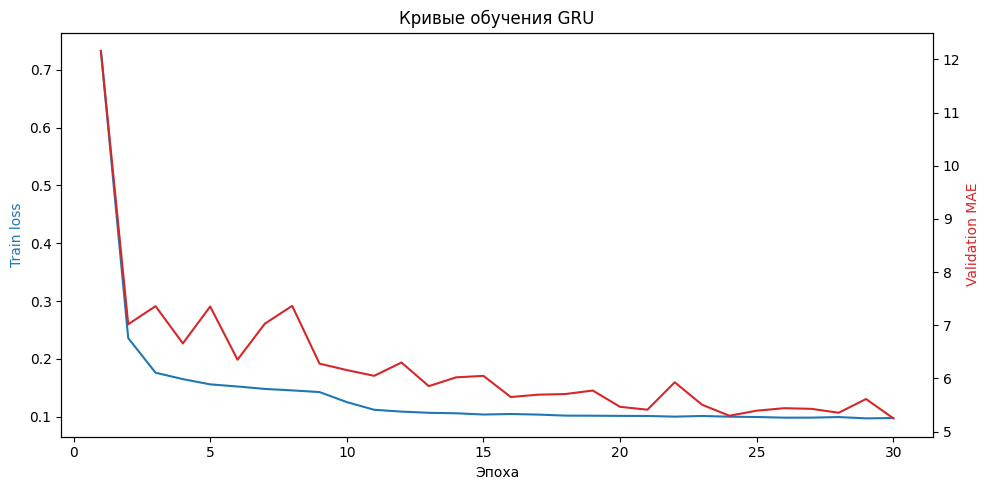

In [5]:
class SequenceDataset(Dataset):
    def __init__(self, values, start_idx, end_idx, window_size):
        xs, ys = [], []
        for t in range(start_idx, end_idx):
            left = t - window_size
            if left < 0:
                continue
            xs.append(values[left:t])
            ys.append(values[t])
        self.x = np.array(xs, dtype=np.float32)
        self.y = np.array(ys, dtype=np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.x[idx]).unsqueeze(-1), torch.tensor(self.y[idx], dtype=torch.float32)


class GRURegressor(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


y_scaler = StandardScaler().fit(y[:n_train].reshape(-1, 1))
y_scaled = y_scaler.transform(y.reshape(-1, 1)).reshape(-1)

train_ds = SequenceDataset(y_scaled, WINDOW_SIZE, n_train, WINDOW_SIZE)
val_ds = SequenceDataset(y_scaled, n_train, n_train + n_val, WINDOW_SIZE)
test_ds = SequenceDataset(y_scaled, n_train + n_val, n, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

r1 = GRURegressor(hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(r1.parameters(), lr=LR)
criterion = nn.MSELoss()

def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
            trues.append(yb.numpy())
    pred_s = np.concatenate(preds)
    true_s = np.concatenate(trues)
    pred = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).reshape(-1)
    true = y_scaler.inverse_transform(true_s.reshape(-1, 1)).reshape(-1)
    return true, pred

history = []
best_state = None
best_val_mae = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    r1.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = r1(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    val_true, val_pred = predict_loader(r1, val_loader)
    val_m = metrics(val_true, val_pred)
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(losses)),
        "val_mae": val_m["mae"],
        "val_rmse": val_m["rmse"],
        "val_mape": val_m["mape"],
    })
    if val_m["mae"] < best_val_mae:
        best_val_mae = val_m["mae"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in r1.state_dict().items()}

r1.load_state_dict(best_state)
torch.save(best_state, ART / "best_gru.pt")

cfg = {
    "model": "GRURegressor",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "hidden_size": HIDDEN_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_epochs": EPOCHS,
    "best_epoch": best_epoch,
    "seed": SEED,
    "scaler": "StandardScaler(train_target_only)",
    "device": str(device),
}
(ART / "best_gru_config.json").write_text(json.dumps(cfg, ensure_ascii=False, indent=2), encoding="utf-8")

r1_val_true, r1_val_pred = predict_loader(r1, val_loader)
r1_val = metrics(r1_val_true, r1_val_pred)
print("R1:", r1_val)

hist_df = pd.DataFrame(history)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hist_df["epoch"], hist_df["train_loss"], color="#1f77b4")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Train loss", color="#1f77b4")
ax2 = ax1.twinx()
ax2.plot(hist_df["epoch"], hist_df["val_mae"], color="#d62728")
ax2.set_ylabel("Validation MAE", color="#d62728")
plt.title("Кривые обучения GRU")
fig.tight_layout()
plt.savefig(FIG / "gru_learning_curves.png", dpi=150)
plt.show()


## 6. Сравнение моделей и финальная test-оценка

Best by validation MAE: R1
Final test: {'mae': 6.029682159423828, 'rmse': 7.698977702261002, 'mape': 3.8621914386749268}


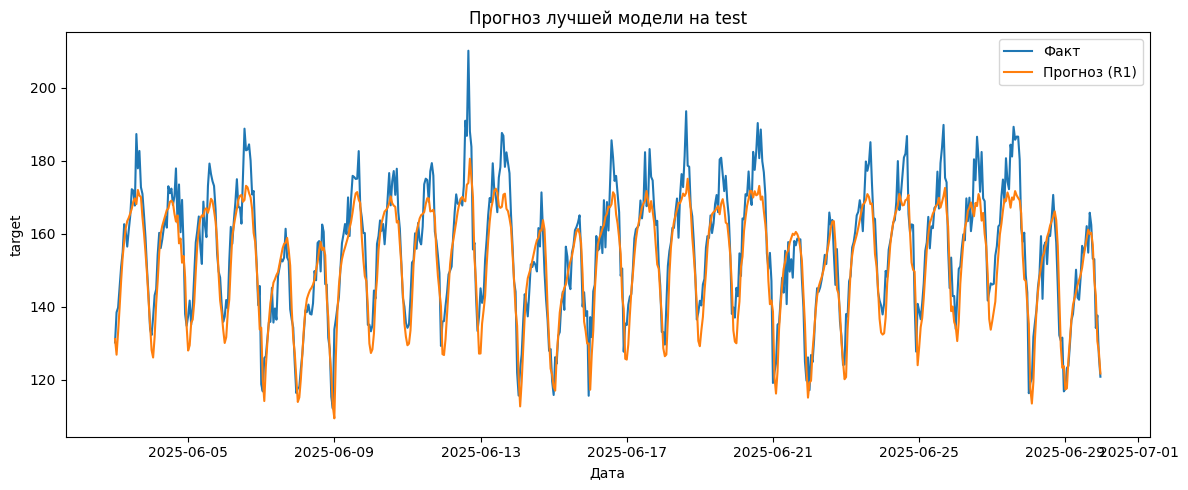

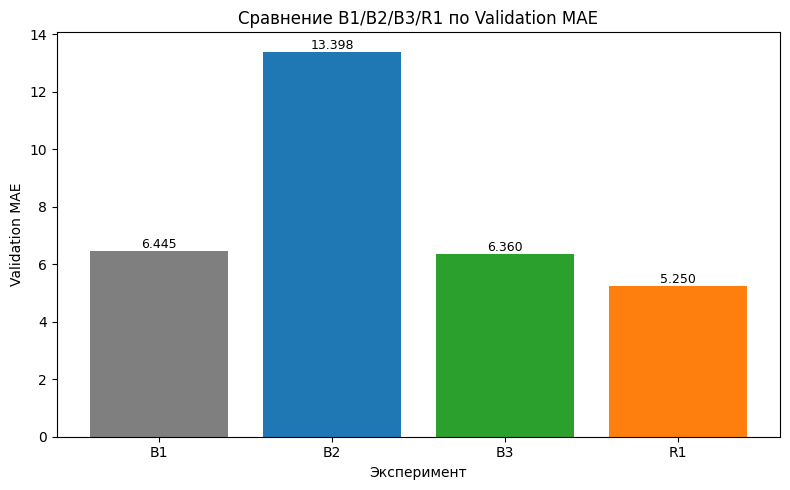

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train: 2025-01-01 00:00:00..2025-05-06 23:00:0...,,1,naive_last,target_lag1_only,none,,,,6.444815,8.201023,4.397922,NaN,NaN,NaN,Naive: y(t-1)
1,B2,forecasting,S12-hw-dataset.csv,42,train: 2025-01-01 00:00:00..2025-05-06 23:00:0...,,1,moving_average,rolling_mean_24_shift1,none,,,,13.397980,16.169904,9.198834,NaN,NaN,NaN,Moving average
2,B3,forecasting,S12-hw-dataset.csv,42,train: 2025-01-01 00:00:00..2025-05-06 23:00:0...,,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...",StandardScaler(train_features_only),,,,6.360191,7.886871,4.282035,NaN,NaN,NaN,Ridge baseline
3,R1,forecasting,S12-hw-dataset.csv,42,train: 2025-01-01 00:00:00..2025-05-06 23:00:0...,24,1,"GRU(hidden_size=64,num_layers=1)",window_target(window=24),StandardScaler(train_target_only),Adam,0.001,30,5.250028,6.840768,3.521656,6.029682,7.698978,3.862191,best_epoch=30


In [6]:
val_map = {"B1": b1_val, "B2": b2_val, "B3": b3_val, "R1": r1_val}
best_id = min(val_map, key=lambda k: val_map[k]["mae"])
print("Best by validation MAE:", best_id)

if best_id == "B1":
    test_true = y[test_slice]
    test_pred = prev[test_slice]
    test_dates = test_df["date"].to_numpy()
elif best_id == "B2":
    test_true = y[test_slice]
    test_pred = ma[test_slice]
    test_dates = test_df["date"].to_numpy()
elif best_id == "B3":
    test_true = y_test_b3
    test_pred = b3.predict(X_test_s)
    test_dates = test_feat["date"].to_numpy()
else:
    test_true, test_pred = predict_loader(r1, test_loader)
    test_dates = test_df["date"].to_numpy()[-len(test_true):]

test_metrics = metrics(test_true, test_pred)
print("Final test:", test_metrics)

plt.figure(figsize=(12, 5))
plt.plot(test_dates, test_true, label="Факт")
plt.plot(test_dates, test_pred, label=f"Прогноз ({best_id})")
plt.title("Прогноз лучшей модели на test")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "best_forecast_test.png", dpi=150)
plt.show()

cmp = pd.DataFrame({
    "experiment_id": ["B1", "B2", "B3", "R1"],
    "val_mae": [b1_val["mae"], b2_val["mae"], b3_val["mae"], r1_val["mae"]],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(cmp["experiment_id"], cmp["val_mae"], color=["#7f7f7f", "#1f77b4", "#2ca02c", "#ff7f0e"])
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2.0, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)
plt.title("Сравнение B1/B2/B3/R1 по Validation MAE")
plt.xlabel("Эксперимент")
plt.ylabel("Validation MAE")
plt.tight_layout()
plt.savefig(FIG / "baselines_compare.png", dpi=150)
plt.show()

split_summary = (
    f"train: {train_df['date'].min()}..{train_df['date'].max()} ({len(train_df)}); "
    f"val: {val_df['date'].min()}..{val_df['date'].max()} ({len(val_df)}); "
    f"test: {test_df['date'].min()}..{test_df['date'].max()} ({len(test_df)})"
)

def make_row(exp_id, val_m, model_summary, features_summary, scaler, optimizer_name, lr_value, epochs_value, notes):
    tm = test_metrics if exp_id == best_id else {"mae": None, "rmse": None, "mape": None}
    return {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE if exp_id == "R1" else "",
        "horizon": HORIZON,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer_name,
        "lr": lr_value,
        "epochs_trained": epochs_value,
        "best_val_mae": val_m["mae"],
        "best_val_rmse": val_m["rmse"],
        "best_val_mape": val_m["mape"],
        "test_mae": tm["mae"],
        "test_rmse": tm["rmse"],
        "test_mape": tm["mape"],
        "notes": notes,
    }

runs = [
    make_row("B1", b1_val, "naive_last", "target_lag1_only", "none", "", "", "", "Naive: y(t-1)"),
    make_row("B2", b2_val, "moving_average", "rolling_mean_24_shift1", "none", "", "", "", "Moving average"),
    make_row("B3", b3_val, "Ridge(alpha=1.0)", "lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,hour", "StandardScaler(train_features_only)", "", "", "", "Ridge baseline"),
    make_row("R1", r1_val, "GRU(hidden_size=64,num_layers=1)", "window_target(window=24)", "StandardScaler(train_target_only)", "Adam", LR, EPOCHS, f"best_epoch={best_epoch}"),
]
pd.DataFrame(runs).to_csv(ART / "runs.csv", index=False)
pd.DataFrame(runs)


## Итог
Все обязательные артефакты сохранены в `./artifacts/`.
Выбор лучшей модели выполнялся только по validation, test использовался один раз для финальной оценки.